In [1]:
import pcdl

mcdsts = pcdl.TimeSeries('output/')

reading: output/PhysiCell_settings.xml
reading: output/output00000000.xml
working on metadata ...
working on mesh data ...
reading: output/initial_mesh0.mat
working on microenvironment data ...
reading: output/output00000000_microenvironment0.mat
parsing: substrate data
working on discrete cell data ...
reading: output/output00000000_cells.mat
working on physiboss data ...
Warning @ TimeStep._read_xml : physiboss file missing output/states_00000000.csv.
working on unit data ...
working on graph data ...
reading: output/output00000000_cell_neighbor_graph.txt
reading: output/output00000000_attached_cells_graph.txt
reading: output/output00000000_spring_attached_cells_graph.txt
done!

reading: output/PhysiCell_settings.xml
reading: output/output00000001.xml
working on metadata ...
working on mesh data ...
reading: output/initial_mesh0.mat
working on microenvironment data ...
reading: output/output00000001_microenvironment0.mat
parsing: substrate data
working on discrete cell data ...
readi

In [2]:
# mcdsts.get_cell_attribute()
import pandas as pd
feature = 'elapsed_time_in_phase'; target_value = 1388.888889
# feature = 'current_cycle_phase_exit_rate'; target_value = 0.000720
df_all = pd.DataFrame(columns=['time', 'cell_id', feature])
for mcds in mcdsts.get_mcds_list():
    time_snapshot = mcds.get_time()
    df_cell = mcds.get_cell_df()
    df_all = pd.concat([df_all, pd.DataFrame({'time': time_snapshot, 'cell_id': df_cell.index, feature: df_cell[feature].values})], ignore_index=True)

/var/folders/z0/qjtn97gj62z2_f7wmwlwkvmc0000gn/T/ipykernel_80636/2849981393.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_all, pd.DataFrame({'time': time_snapshot, 'cell_id': df_cell.index, feature: df_cell[feature].values})], ignore_index=True)


/var/folders/z0/qjtn97gj62z2_f7wmwlwkvmc0000gn/T/ipykernel_80636/1021219041.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_all_plot, x=feature, hue="time", common_norm=True)


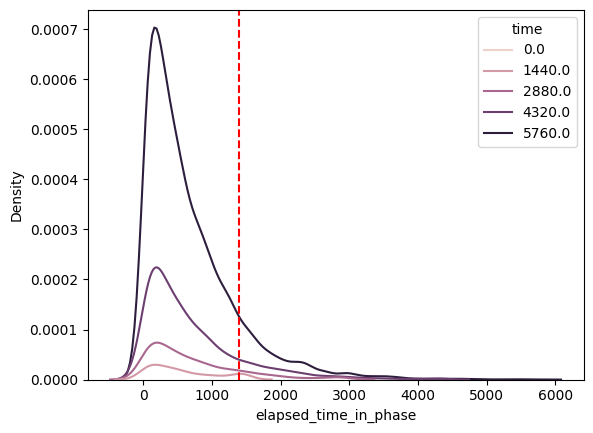

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

times = [0, 1440, 2880, 4320, 5760, 7200]
# drop rows with time not in times
df_all_plot = df_all[df_all['time'].isin(times)]
sns.kdeplot(data=df_all_plot, x=feature, hue="time", common_norm=True)
plt.axvline(x=target_value, color='r', linestyle='--', label='Reference Value')